### **Cell 1: Import the dependencies**
- This code block imports all the necessary libraries and modules used in this project.



In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,BatchNormalization, Activation,
    GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

---------------------------------------------------------------------------
## **Download Dataset through Kaggle API**

In [ ]:
import json
import os

KAGGLE_USERNAME = "boeyleong13"
KAGGLE_KEY = "KGAT_7da4632cb4493953080c740e710f70ab"

kaggle_dict = {
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_KEY
}

dest_dir = os.path.expanduser("~/.kaggle")
os.makedirs(dest_dir, exist_ok=True)

with open(os.path.join(dest_dir, "kaggle.json"), "w") as f:
    json.dump(kaggle_dict, f)

# 权限
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API is ready at:", dest_dir)

Kaggle API is ready at: C:\Users\baoye/.kaggle


'chmod' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p ./data

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:25<00:00, 117MB/s]
100% 2.29G/2.29G [00:25<00:00, 98.1MB/s]


In [ ]:
import zipfile

zip_path = "./data/chest-xray-pneumonia.zip"
extract_path = "./data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped!")


Dataset unzipped!


---

### **Cell 2：Path & Basic Data Statistics**
- This block checks whether the dataset has been extracted correctly and displays the number of images in each category (NORMAL and PNEUMONIA) across the train, validation, and test sets.

In [ ]:
import os

base_dir = "./data/chest_xray"

print("Items in base_dir:", os.listdir(base_dir))

train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

for split in ["train", "val", "test"]:
    split_dir = os.path.join(base_dir, split)
    normal_count = len(os.listdir(os.path.join(split_dir, "NORMAL")))
    pneu_count   = len(os.listdir(os.path.join(split_dir, "PNEUMONIA")))
    print(f"{split.capitalize():5}: {normal_count:4d} NORMAL, {pneu_count:4d} PNEUMONIA")

print("\nNote: The original 'val' folder only contains 16 images and will NOT be used for validation.")


Items in base_dir: ['chest_xray', 'test', 'train', 'val', '__MACOSX']
Train: 1341 NORMAL, 3875 PNEUMONIA
Val  :    8 NORMAL,    8 PNEUMONIA
Test :  234 NORMAL,  390 PNEUMONIA

Note: The original 'val' folder only contains 16 images and will NOT be used for validation.


---
## Part A：CNN Model
---

### **Cell 3 - Data Preparation for CNN (Training, Validation, and Testing Generators)**


In [ ]:
img_size_cnn = (224, 224)
batch_size_cnn = 32
val_split = 0.2   # 20% of the training set is used as the val set

# Training Generator
train_datagen_cnn = ImageDataGenerator(

    #Normalization
    rescale=1.0/255,

    #data augmentation
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,

    validation_split=val_split,
)

# Training / Validation Subsets
train_gen = train_datagen_cnn.flow_from_directory(
    train_dir,
    target_size=img_size_cnn,
    batch_size=batch_size_cnn,
    class_mode="binary",
    subset="training",
    shuffle=True,
)

val_gen = train_datagen_cnn.flow_from_directory(
    train_dir,
    target_size=img_size_cnn,
    batch_size=batch_size_cnn,
    class_mode="binary",
    subset="validation",
    shuffle=False,
)

# Test Generator
test_datagen_cnn = ImageDataGenerator(rescale=1.0/255)

test_gen = test_datagen_cnn.flow_from_directory(
    test_dir,
    target_size=img_size_cnn,
    batch_size=batch_size_cnn,
    class_mode="binary",
    shuffle=False,
)

print("CNN class indices:", train_gen.class_indices)
print(f"CNN train samples: {train_gen.samples}, val samples: {val_gen.samples}, test samples: {test_gen.samples}")


Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
CNN class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
CNN train samples: 4173, val samples: 1043, test samples: 624


---
### **Cell 4 - CNN Model Architecture**

In [ ]:
input_shape = (img_size_cnn[0], img_size_cnn[1], 3)

cnn_model = Sequential([
    # Block 1
    Conv2D(32, (3,3), padding='same', input_shape=input_shape),
    BatchNormalization(), #stabilize training
    Activation('relu'),
    MaxPooling2D(2,2), #spatial downsampling

    # Block 2
    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2,2),

    # Block 4
    Conv2D(256, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2,2),

    Flatten(), #convert feature maps into a 1D vector

    Dense(256),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5), #prevent overfitting

    # Output layer
    Dense(1, activation='sigmoid')  # binary classification (Normal vs Pneumonia)
])

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 32)     128       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 224, 224, 32)      0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 batch_normalization_1 (Batc  (None, 112, 112, 64)     2

---
### **Cell 5 - Callbacks for CNN Training**


In [ ]:
checkpoint_path_cnn = "best_cnn_model.h5"

early_stop_cnn = EarlyStopping(
    monitor='val_accuracy',
    patience=5,                # will stop after 5 ephco
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr_cnn = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

model_ckpt_cnn = ModelCheckpoint(
    checkpoint_path_cnn,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

callbacks_cnn = [early_stop_cnn, reduce_lr_cnn, model_ckpt_cnn]

---
### **Cell 6 - Training the CNN (with class weights)**

In [ ]:
class_weight_cnn = {
    0: 1.5,  # NORMAL
    1: 1.0,  # PNEUMONIA
}

epochs_cnn = 20

history = cnn_model.fit(
    train_gen,
    epochs=epochs_cnn,
    validation_data=val_gen,
    callbacks=callbacks_cnn,
    class_weight=class_weight_cnn,
)


Epoch 1/20
131/131 [==============================] - ETA: 0s - loss: 0.1079 - accuracy: 0.9676
Epoch 1: val_accuracy improved from -inf to 0.94727, saving model to best_cnn_model.h5
131/131 [==============================] - 163s 1s/step - loss: 0.1079 - accuracy: 0.9676 - val_loss: 0.1397 - val_accuracy: 0.9473 - lr: 1.2500e-04
Epoch 2/20
131/131 [==============================] - ETA: 0s - loss: 0.1064 - accuracy: 0.9655
Epoch 2: val_accuracy did not improve from 0.94727
131/131 [==============================] - 152s 1s/step - loss: 0.1064 - accuracy: 0.9655 - val_loss: 1.1247 - val_accuracy: 0.6136 - lr: 1.2500e-04
Epoch 3/20
131/131 [==============================] - ETA: 0s - loss: 0.0955 - accuracy: 0.9688
Epoch 3: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 3: val_accuracy did not improve from 0.94727
131/131 [==============================] - 159s 1s/step - loss: 0.0955 - accuracy: 0.9688 - val_loss: 0.5937 - val_accuracy: 0.8207 - lr: 1.2500e-04


---
### **Cell 7 - CNN Training and Validation Curves**

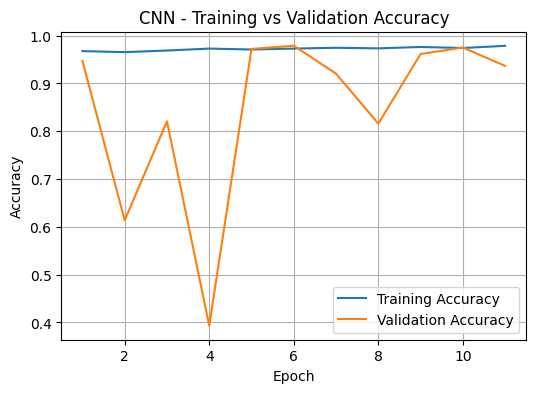

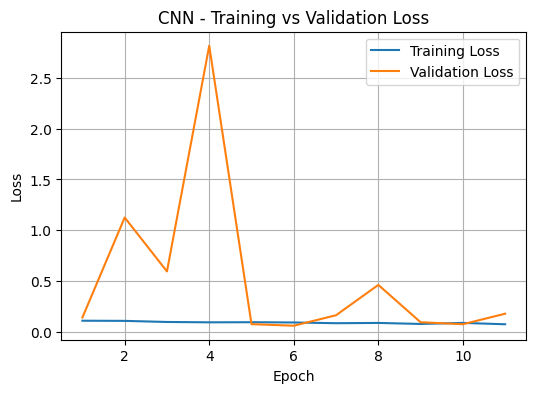

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_ran = range(1, len(acc) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs_ran, acc, label="Training Accuracy")
plt.plot(epochs_ran, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN - Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs_ran, loss, label="Training Loss")
plt.plot(epochs_ran, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN - Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


---
### **Cell 8 - CNN Confusion Matrix / Report / AUC / ROC**


20/20 [==============================] - 8s 397ms/step
CNN - Confusion Matrix:
[[188  46]
 [ 12 378]]


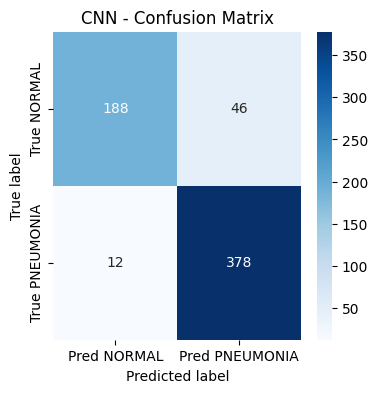

CNN - Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.94      0.80      0.87       234
   PNEUMONIA       0.89      0.97      0.93       390

    accuracy                           0.91       624
   macro avg       0.92      0.89      0.90       624
weighted avg       0.91      0.91      0.91       624

CNN AUC: 0.9613


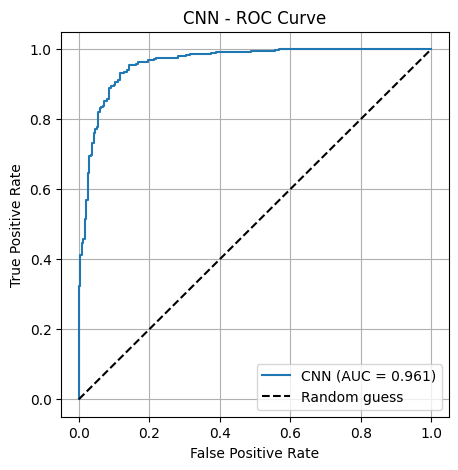

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predictions
#predicted probabilities (before threshold)
y_prob_cnn = cnn_model.predict(test_gen).ravel()
y_true_cnn = test_gen.classes
#final class predictions using a 0.5 threshold
y_pred_cnn = (y_prob_cnn > 0.5).astype(int).flatten()

# Confusion Matrix
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
print("CNN - Confusion Matrix:")
print(cm_cnn)

plt.figure(figsize=(4, 4))
sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred NORMAL", "Pred PNEUMONIA"],
    yticklabels=["True NORMAL", "True PNEUMONIA"],
)
plt.title("CNN - Confusion Matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

# Classification Report
print("CNN - Classification Report:")
print(
    classification_report(
        y_true_cnn,
        y_pred_cnn,
        target_names=["NORMAL", "PNEUMONIA"],
    )
)

# AUC & ROC
auc_cnn = roc_auc_score(y_true_cnn, y_prob_cnn)
print(f"CNN AUC: {auc_cnn:.4f}")

fpr_cnn, tpr_cnn, _ = roc_curve(y_true_cnn, y_prob_cnn)

plt.figure(figsize=(5, 5))
plt.plot(fpr_cnn, tpr_cnn, label=f"CNN (AUC = {auc_cnn:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CNN - ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


---
## Part B：EfficientNetB0 Model
---

### **Cell 9：EfficientNetB0 ImageDataGenerator**

In [ ]:
img_size_eff = (224, 224)
batch_size_eff = 32
val_split = 0.2   # same to CNN

# Unified Data Generator
datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=val_split,
)

# Training / Validation Subsets
train_gen_eff = datagen_eff.flow_from_directory(
    train_dir,
    target_size=img_size_eff,
    batch_size=batch_size_eff,
    class_mode="binary",
    subset="training",
    shuffle=True,
)

val_gen_eff = datagen_eff.flow_from_directory(
    train_dir,
    target_size=img_size_eff,
    batch_size=batch_size_eff,
    class_mode="binary",
    subset="validation",
    shuffle=False,
)

# Test Generator
test_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_gen_eff = test_datagen_eff.flow_from_directory(
    test_dir,
    target_size=img_size_eff,
    batch_size=batch_size_eff,
    class_mode="binary",
    shuffle=False,
)

print("EfficientNetB0 class indices:", train_gen_eff.class_indices)
print(f"Eff train samples: {train_gen_eff.samples}, val samples: {val_gen_eff.samples}, test samples: {test_gen_eff.samples}")


Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
EfficientNetB0 class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Eff train samples: 4173, val samples: 1043, test samples: 624


---
### **Cell 10 - EfficientNetB0 Model (Stage 1: Frozen Backbone)**

In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
)

# 冻结 backbone
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)

model_effnet = Model(inputs=base_model.input, outputs=output)

model_effnet.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model_effnet.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

---
### **Cell 11 - EfficientNet callbacks**

In [ ]:
checkpoint_path_eff = "best_effnetb0_stage1.h5"

early_stop_eff = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_eff = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

model_ckpt_eff = ModelCheckpoint(
    checkpoint_path_eff,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

callbacks_eff = [early_stop_eff, reduce_lr_eff, model_ckpt_eff]

---
### **Cell 12 -Training EfficientNetB0 (Stage 1: Frozen Backbone)**

In [ ]:
history_eff_stage1 = model_effnet.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=8,
    callbacks=callbacks_eff,
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - accuracy: 0.8163 - loss: 0.4154
Epoch 1: val_loss improved from inf to 0.21898, saving model to best_effnetb0_stage1.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.8166 - loss: 0.4148 - val_accuracy: 0.9118 - val_loss: 0.2190 - learning_rate: 0.0010
Epoch 2/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.8978 - loss: 0.2259
Epoch 2: val_loss improved from 0.21898 to 0.17052, saving model to best_effnetb0_stage1.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 97s 742ms/step - accuracy: 0.8979 - loss: 0.2259 - val_accuracy: 0.9348 - val_loss: 0.1705 - learning_rate: 0.0010
Epoch 3/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.9143 - loss: 0.2008
Epoch 3: val_loss improved from 0.17052 to 0.15640, saving model to best_effnetb0_stage1.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 96s 736ms/step - accuracy: 0.9144 - loss: 0.2007 - val_accuracy: 0.9386 - val_loss: 0.1564 - learning_rate: 0.0010
Epoch 4/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.9329 - loss: 0.1756
Epoch 4: val_loss improved from 0.15640 to 0.15589, saving model to best_effnetb0_stage1.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 95s 729ms/step - accuracy: 0.9328 - loss: 0.1756 - val_accuracy: 0.9338 - val_loss: 0.1559 - learning_rate: 0.0010
Epoch 5/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.9325 - loss: 0.1722
Epoch 5: val_loss improved from 0.15589 to 0.14207, saving model to best_effnetb0_stage1.h5



131/131 ━━━━━━━━━━━━━━━━━━━━ 95s 722ms/step - accuracy: 0.9325 - loss: 0.1722 - val_accuracy: 0.9473 - val_loss: 0.1421 - learning_rate: 0.0010
Epoch 6/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.9329 - loss: 0.1673
Epoch 6: val_loss improved from 0.14207 to 0.13825, saving model to best_effnetb0_stage1.h5



131/131 ━━━━━━━━━━━━━━━━━━━━ 96s 728ms/step - accuracy: 0.9329 - loss: 0.1672 - val_accuracy: 0.9434 - val_loss: 0.1382 - learning_rate: 0.0010
Epoch 7/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.9335 - loss: 0.1708
Epoch 7: val_loss improved from 0.13825 to 0.12764, saving model to best_effnetb0_stage1.h5



131/131 ━━━━━━━━━━━━━━━━━━━━ 97s 739ms/step - accuracy: 0.9335 - loss: 0.1707 - val_accuracy: 0.9549 - val_loss: 0.1276 - learning_rate: 0.0010
Epoch 8/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.9390 - loss: 0.1600
Epoch 8: val_loss did not improve from 0.12764
131/131 ━━━━━━━━━━━━━━━━━━━━ 96s 734ms/step - accuracy: 0.9390 - loss: 0.1599 - val_accuracy: 0.9406 - val_loss: 0.1416 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 7.


---
### **Cell 13 - EfficientNetB0 Fine-Tuning (Stage 2)**

In [ ]:
# Unfreezing
base_model.trainable = True

for layer in base_model.layers[:-100]:
    layer.trainable = False

model_effnet.compile(
    optimizer=Adam(learning_rate=1e-5),  # Prevents damaging pretrained ImageNet weights
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

checkpoint_path_eff2 = "best_effnetb0_stage2.h5"

model_ckpt_eff2 = ModelCheckpoint(
    checkpoint_path_eff2,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history_eff_stage2 = model_effnet.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=10,
    callbacks=[early_stop_eff, reduce_lr_eff, model_ckpt_eff2]
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 749ms/step - accuracy: 0.8515 - loss: 0.3865
Epoch 1: val_loss improved from inf to 0.26179, saving model to best_effnetb0_stage2.h5



131/131 ━━━━━━━━━━━━━━━━━━━━ 178s 999ms/step - accuracy: 0.8516 - loss: 0.3862 - val_accuracy: 0.8936 - val_loss: 0.2618 - learning_rate: 1.0000e-05
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.9077 - loss: 0.2581
Epoch 2: val_loss improved from 0.26179 to 0.17166, saving model to best_effnetb0_stage2.h5



131/131 ━━━━━━━━━━━━━━━━━━━━ 99s 753ms/step - accuracy: 0.9078 - loss: 0.2580 - val_accuracy: 0.9386 - val_loss: 0.1717 - learning_rate: 1.0000e-05
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.9190 - loss: 0.2199
Epoch 3: val_loss improved from 0.17166 to 0.14314, saving model to best_effnetb0_stage2.h5



131/131 ━━━━━━━━━━━━━━━━━━━━ 98s 749ms/step - accuracy: 0.9191 - loss: 0.2198 - val_accuracy: 0.9521 - val_loss: 0.1431 - learning_rate: 1.0000e-05
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.9355 - loss: 0.1804
Epoch 4: val_loss improved from 0.14314 to 0.14055, saving model to best_effnetb0_stage2.h5



131/131 ━━━━━━━━━━━━━━━━━━━━ 99s 753ms/step - accuracy: 0.9355 - loss: 0.1803 - val_accuracy: 0.9521 - val_loss: 0.1405 - learning_rate: 1.0000e-05
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.9494 - loss: 0.1549
Epoch 5: val_loss improved from 0.14055 to 0.10263, saving model to best_effnetb0_stage2.h5


...


131/131 ━━━━━━━━━━━━━━━━━━━━ 98s 746ms/step - accuracy: 0.9567 - loss: 0.1274 - val_accuracy: 0.9703 - val_loss: 0.0903 - learning_rate: 1.0000e-05
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.9629 - loss: 0.1149
Epoch 7: val_loss improved from 0.09028 to 0.08642, saving model to best_effnetb0_stage2.h5



131/131 ━━━━━━━━━━━━━━━━━━━━ 98s 749ms/step - accuracy: 0.9629 - loss: 0.1149 - val_accuracy: 0.9741 - val_loss: 0.0864 - learning_rate: 1.0000e-05
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.9581 - loss: 0.1228
Epoch 8: val_loss improved from 0.08642 to 0.08075, saving model to best_effnetb0_stage2.h5



131/131 ━━━━━━━━━━━━━━━━━━━━ 98s 744ms/step - accuracy: 0.9581 - loss: 0.1227 - val_accuracy: 0.9732 - val_loss: 0.0808 - learning_rate: 1.0000e-05
Epoch 9/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.9641 - loss: 0.0951
Epoch 9: val_loss improved from 0.08075 to 0.08072, saving model to best_effnetb0_stage2.h5



131/131 ━━━━━━━━━━━━━━━━━━━━ 99s 753ms/step - accuracy: 0.9641 - loss: 0.0951 - val_accuracy: 0.9741 - val_loss: 0.0807 - learning_rate: 1.0000e-05
Epoch 10/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.9633 - loss: 0.0985
Epoch 10: val_loss improved from 0.08072 to 0.07422, saving model to best_effnetb0_stage2.h5



131/131 ━━━━━━━━━━━━━━━━━━━━ 99s 751ms/step - accuracy: 0.9633 - loss: 0.0985 - val_accuracy: 0.9770 - val_loss: 0.0742 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 10.


---
### **Cell 14 - EfficientNetB0 Training Curves (Stage 1 + Stage 2)**

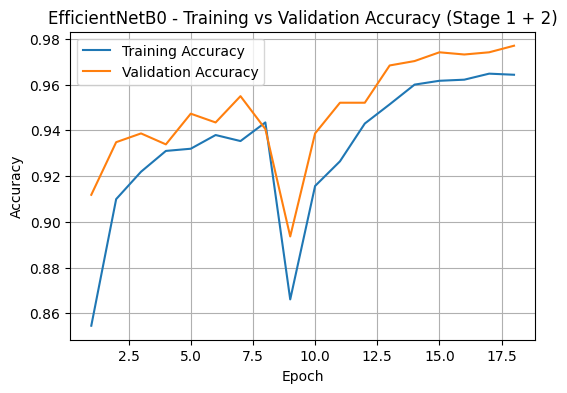

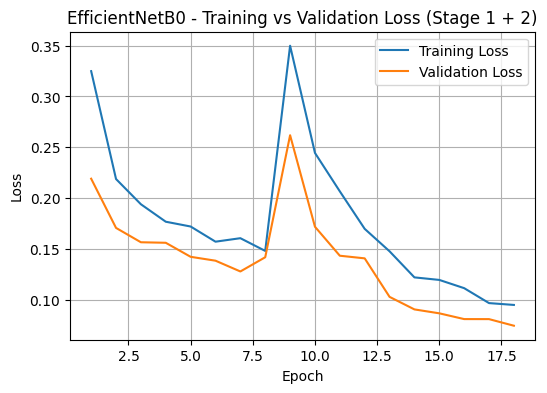

In [ ]:
# combine stage 1 and stage 2
acc_eff = (
    history_eff_stage1.history["accuracy"]
    + history_eff_stage2.history["accuracy"]
)
val_acc_eff = (
    history_eff_stage1.history["val_accuracy"]
    + history_eff_stage2.history["val_accuracy"]
)
loss_eff = (
    history_eff_stage1.history["loss"]
    + history_eff_stage2.history["loss"]
)
val_loss_eff = (
    history_eff_stage1.history["val_loss"]
    + history_eff_stage2.history["val_loss"]
)

epochs_eff = range(1, len(acc_eff) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs_eff, acc_eff, label="Training Accuracy")
plt.plot(epochs_eff, val_acc_eff, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 - Training vs Validation Accuracy (Stage 1 + 2)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs_eff, loss_eff, label="Training Loss")
plt.plot(epochs_eff, val_loss_eff, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 - Training vs Validation Loss (Stage 1 + 2)")
plt.legend()
plt.grid(True)
plt.show()

---
### **Cell 15：EfficientNet Confusion Matrix / Report / AUC / ROC**

20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 564ms/step
EfficientNetB0 - Confusion Matrix:
[[187  47]
 [ 13 377]]


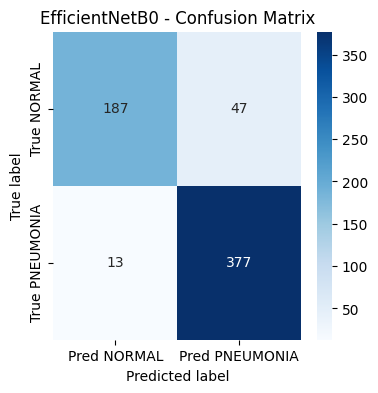

EfficientNetB0 - Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.94      0.80      0.86       234
   PNEUMONIA       0.89      0.97      0.93       390

    accuracy                           0.90       624
   macro avg       0.91      0.88      0.89       624
weighted avg       0.91      0.90      0.90       624

EfficientNetB0 AUC: 0.9673


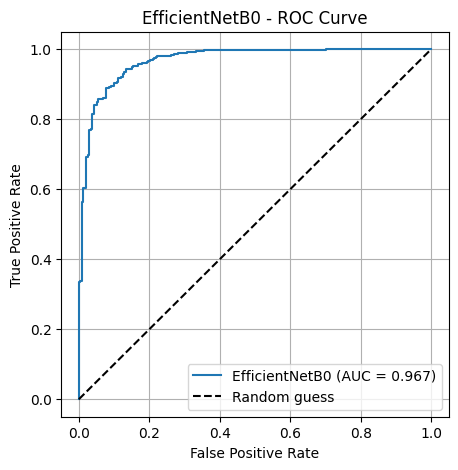

In [ ]:
# predictions
y_prob_eff = model_effnet.predict(test_gen_eff).ravel()
y_true_eff = test_gen_eff.classes
y_pred_eff = (y_prob_eff > 0.5).astype(int)

# confusion matrix
cm_eff = confusion_matrix(y_true_eff, y_pred_eff)
print("EfficientNetB0 - Confusion Matrix:")
print(cm_eff)

plt.figure(figsize=(4, 4))
sns.heatmap(
    cm_eff,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred NORMAL", "Pred PNEUMONIA"],
    yticklabels=["True NORMAL", "True PNEUMONIA"],
)
plt.title("EfficientNetB0 - Confusion Matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

# Classification Report
print("EfficientNetB0 - Classification Report:")
print(
    classification_report(
        y_true_eff,
        y_pred_eff,
        target_names=["NORMAL", "PNEUMONIA"],
    )
)

# AUC & ROC
auc_eff = roc_auc_score(y_true_eff, y_prob_eff)
print(f"EfficientNetB0 AUC: {auc_eff:.4f}")

fpr_eff, tpr_eff, _ = roc_curve(y_true_eff, y_prob_eff)

plt.figure(figsize=(5, 5))
plt.plot(fpr_eff, tpr_eff, label=f"EfficientNetB0 (AUC = {auc_eff:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("EfficientNetB0 - ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
